In [2]:
import pandas as pd

# Laeme sisse EDA märkmikus puhastatud ja salvestatud andmestiku
df_cleaned = pd.read_parquet('data/cleaned_reports_for_modeling.parquet')
print("Puhastatud andmed laetud edukalt! Ridade arv:", len(df_cleaned))

Puhastatud andmed laetud edukalt! Ridade arv: 1374020


In [4]:
# Andmete ettevalmistus mudelite jaoks
# Sorteerime andmed ettevõtte ja aasta järgi
df_model = df_cleaned.sort_values(by=['registrikood', 'aruandeaasta']).copy()

# Leiame iga ettevõtte jaoks järgmise aasta kasumi/kahjumi ja staatuse
df_model['NextYear_ProfitLoss'] = df_model.groupby('registrikood')['TotalAnnualPeriodProfitLoss'].shift(-1)
df_model['NextYear_Status'] = df_model.groupby('registrikood')['staatus'].shift(-1)

# Loome sihtmuutujad (target variables)
# 1. Mudel: Järgmise aasta kasum (1 = kasum, 0 = kahjum või null)
df_model['Target_Profit'] = (df_model['NextYear_ProfitLoss'] > 0).astype(int)

# 2. Mudel: Järgmise aasta staatus (1 = Registrisse kantud (Aktiivne), 0 = Kustutatud/Pankrotis/Likvideerimisel)
# ~ operaator muudab tõeväärtused vastupidiseks: kui on kustutatud/pankrotis, siis on 0, muidu 1.
df_model['Target_Status'] = (~df_model['NextYear_Status'].isin(['Kustutatud', 'Pankrotis', 'Likvideerimisel'])).astype(int) 

# Jätame alles ainult need read, kus meil on järgmise aasta andmed olemas (ehk shift(-1) ei ole NaN)
# Erandiks staatus, kus võime teada, et järgmisel aastal andmeid pole, mis võibki viidata kustutamisele,
# aga praegu kasutame puhast shifti.
df_model_ready = df_model.dropna(subset=['NextYear_ProfitLoss', 'NextYear_Status']).copy()

print(f"Andmeridade arv mudeli treenimiseks: {len(df_model_ready)}")
df_model_ready[['registrikood', 'aruandeaasta', 'TotalAnnualPeriodProfitLoss', 'staatus', 'NextYear_ProfitLoss', 'NextYear_Status', 'Target_Profit', 'Target_Status']].head()

Andmeridade arv mudeli treenimiseks: 1073870


,registrikood,aruandeaasta,TotalAnnualPeriodProfitLoss,staatus,NextYear_ProfitLoss,NextYear_Status,Target_Profit,Target_Status
47587,10000018,2019,1506266.0,Registrisse kantud,1321525.0,Registrisse kantud,1,1
221151,10000018,2020,1321525.0,Registrisse kantud,5785994.0,Registrisse kantud,1,1
427409,10000018,2021,5785994.0,Registrisse kantud,1338647.0,Registrisse kantud,1,1
649955,10000018,2022,1338647.0,Registrisse kantud,3540437.0,Registrisse kantud,1,1
901565,10000018,2023,3540437.0,Registrisse kantud,3532612.0,Registrisse kantud,1,1


### Mudel 1: Järgmise aasta kasumi ennustamine

Kasutame Random Forest klassifikaatorit. Ennustame, kas ettevõte on järgmisel aastal kasumis (`Target_Profit` == 1).

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Valime numbrilised tunnused mudeli jaoks
possible_features = ['Assets', 'Töötajate_arv', 'CurrentAssets', 'CurrentLiabilities', 
            'Equity', 'IssuedCapital', 'LaborExpense', 'RetainedEarningsLoss', 
            'Revenue', 'TotalAnnualPeriodProfitLoss']

# Tagame, et kasutame ainult neid veerge, mis eksisteerivad tabelis
features = [f for f in possible_features if f in df_model_ready.columns]

# Arvutame protsendi kõigist
profit_percentage = (df_model_ready['Target_Profit'].sum() / len(df_model_ready)) * 100
print(f"Kõigist ettevõtetest jääb järgmisel aastal kasumisse: {profit_percentage:.2f}%\n")

# Et mudeli treenimine ei võtaks üleliia kaua aega, võtame 100 000 reast koosneva juhusliku valimi
# (Kuna andmeid on ca 1 miljon)
df_sample = df_model_ready.sample(n=min(100000, len(df_model_ready)), random_state=42)

X = df_sample[features].fillna(0)
y1 = df_sample['Target_Profit']

X_train1, X_test1, y_train1, y_test1 = train_test_split(X, y1, test_size=0.2, random_state=42)

# Kasutame juhuslikku metsa mudelit (Random Forest)
rf_model1 = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1, max_depth=10)
rf_model1.fit(X_train1, y_train1)
y_pred1 = rf_model1.predict(X_test1)

print("--- Mudel 1 (Järgmise aasta kasum) tulemused ---")
print(f"Täpsus (Accuracy): {accuracy_score(y_test1, y_pred1):.4f}")
print(classification_report(y_test1, y_pred1))

Kõigist ettevõtetest jääb järgmisel aastal kasumisse: 48.30%

--- Mudel 1 (Järgmise aasta kasum) tulemused ---
Täpsus (Accuracy): 0.7569
              precision    recall  f1-score   support

           0       0.84      0.66      0.74     10338
           1       0.70      0.87      0.77      9662

    accuracy                           0.76     20000
   macro avg       0.77      0.76      0.76     20000
weighted avg       0.77      0.76      0.75     20000



### Mudel 2: Staatuse muutumise ennustamine

Mudel ennustab, kas ettevõte on järgmisel aastal aktiivne (Registrisse kantud) või mitte (Kustutatud, Pankrotis, Likvideerimisel). `Target_Status` on 1, kui ettevõte on aktiivne, ja 0, kui see on kustutatud/pankrotis.

In [6]:
# Mudel 2: Järgmise aasta staatus (1 = Registrisse kantud, 0 = Kustutatud/Pankrotis/Likvideerimisel)

# Pöörame protsendi arvutamise loogika ümber
status_percentage = (df_model_ready['Target_Status'].sum() / len(df_model_ready)) * 100
print(f"Kõigist ettevõtetest on järgmisel aastal Aktiivsed (Registrisse kantud): {status_percentage:.2f}%\n")

y2 = df_sample['Target_Status']

X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y2, test_size=0.2, random_state=42)

rf_model2 = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1, max_depth=10, class_weight='balanced')
rf_model2.fit(X_train2, y_train2)
y_pred2 = rf_model2.predict(X_test2)

print("--- Mudel 2 (Järgmise aasta staatus) tulemused ---")
print(f"Täpsus (Accuracy): {accuracy_score(y_test2, y_pred2):.4f}")
print(classification_report(y_test2, y_pred2))

Kõigist ettevõtetest on järgmisel aastal Aktiivsed (Registrisse kantud): 93.07%

--- Mudel 2 (Järgmise aasta staatus) tulemused ---
Täpsus (Accuracy): 0.7605
              precision    recall  f1-score   support

           0       0.15      0.55      0.24      1387
           1       0.96      0.78      0.86     18613

    accuracy                           0.76     20000
   macro avg       0.56      0.66      0.55     20000
weighted avg       0.90      0.76      0.82     20000



### Tunnuste olulisus (Feature Importance)

Vaatame, millised finantsnäitajad mõjutavad kõige enam ettevõtte kasumisse jäämist või pankrotti/kustutamist.

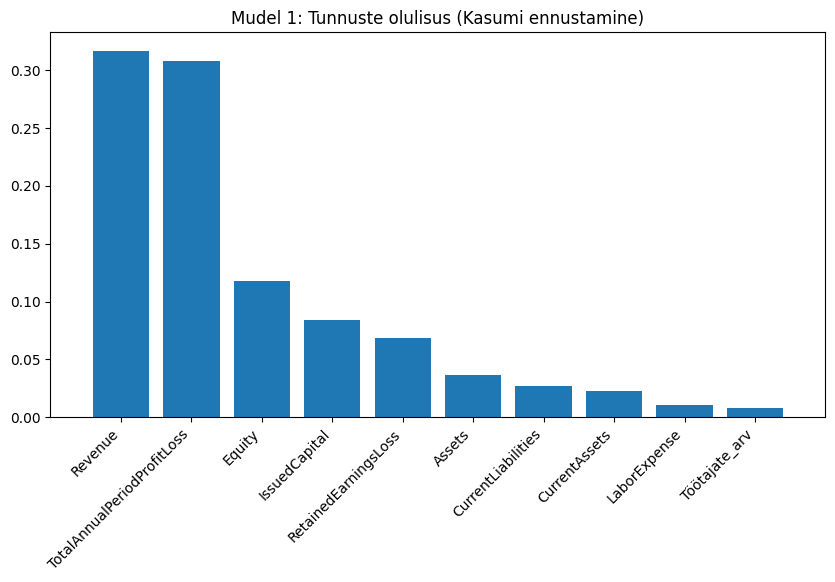

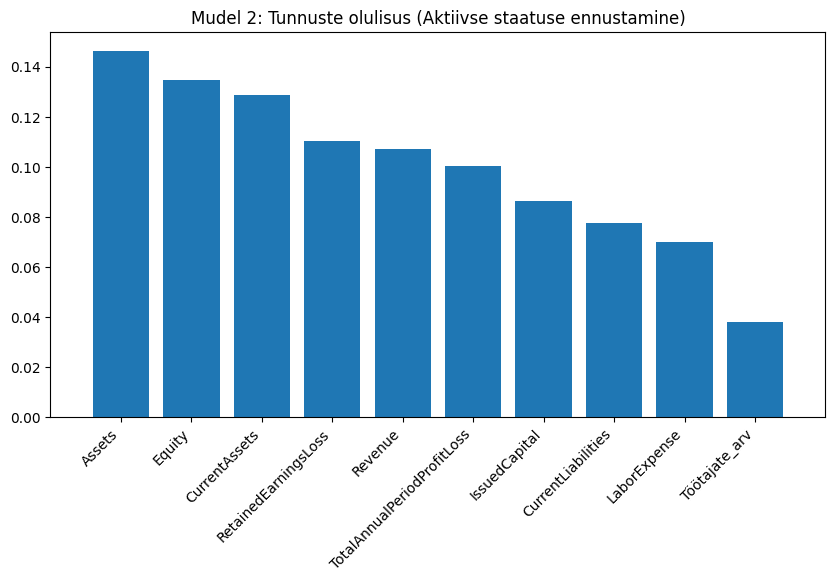

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Mudel 1 (Kasumi ennustamine) tunnuste olulisus
importances1 = rf_model1.feature_importances_
indices1 = np.argsort(importances1)[::-1]

plt.figure(figsize=(10, 5))
plt.title("Mudel 1: Tunnuste olulisus (Kasumi ennustamine)")
plt.bar(range(X.shape[1]), importances1[indices1], align="center")
plt.xticks(range(X.shape[1]), [features[i] for i in indices1], rotation=45, ha='right')
plt.xlim([-1, X.shape[1]])
plt.show()

# Mudel 2 (Aktiivse staatuse ennustamine) tunnuste olulisus
importances2 = rf_model2.feature_importances_
indices2 = np.argsort(importances2)[::-1]

plt.figure(figsize=(10, 5))
plt.title("Mudel 2: Tunnuste olulisus (Aktiivse staatuse ennustamine)")
plt.bar(range(X.shape[1]), importances2[indices2], align="center")
plt.xticks(range(X.shape[1]), [features[i] for i in indices2], rotation=45, ha='right')
plt.xlim([-1, X.shape[1]])
plt.show()